In [39]:
import pandas as pd
import os
import numpy as np

In [40]:
metadata = pd.read_csv("/kaggle/input/nasa-battery-dataset/cleaned_dataset/metadata.csv")
metadata

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7560,impedance,[2010. 9. 30. 7. 36. ...,24,B0055,247,7561,07561.csv,NaN,0.0968087979207628,0.15489738203707232
7561,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.0201379996149256,NaN,NaN
7562,charge,[2010. 9. 30. 8. 48. 54.25],4,B0055,249,7563,07563.csv,NaN,NaN,NaN
7563,discharge,[2010. 9. 30. 11. 50. ...,4,B0055,250,7564,07564.csv,0.9907591663373165,NaN,NaN


In [41]:
discharge = metadata[metadata['type']== 'discharge']

In [42]:
discharge

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.5080762969973425,NaN,NaN
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.4835577960067696,NaN,NaN
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.4671391666146525,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7553,discharge,[2010. 9. 29. 19. 50. ...,4,B0055,240,7554,07554.csv,1.0285269676595319,NaN,NaN
7555,discharge,[2.01e+03 9.00e+00 2.90e+01 2.30e+01 3.30e+01 ...,4,B0055,242,7556,07556.csv,0.9816844358987022,NaN,NaN
7557,discharge,[2010. 9. 30. 3. 15. ...,4,B0055,244,7558,07558.csv,1.0127121434171131,NaN,NaN
7561,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.0201379996149256,NaN,NaN


In [43]:
discharge.isnull().sum()

type                      0
start_time                0
ambient_temperature       0
battery_id                0
test_id                   0
uid                       0
filename                  0
Capacity                  0
Re                     2794
Rct                    2794
dtype: int64

In [44]:
discharge.drop(['Re','Rct'], axis = 1, inplace = True)

/tmp/ipykernel_47/1194253541.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [45]:
discharge['battery_id'].value_counts()

battery_id
B0033    197
B0036    197
B0034    197
B0007    168
B0005    168
B0006    168
B0018    132
B0044    112
B0043    112
B0042    112
B0054    103
B0056    102
B0055    102
B0047     72
B0048     72
B0045     72
B0046     72
B0041     67
B0053     56
B0040     47
B0039     47
B0038     47
B0030     40
B0029     40
B0031     40
B0032     40
B0026     28
B0025     28
B0028     28
B0027     28
B0049     25
B0052     25
B0051     25
B0050     25
Name: count, dtype: int64

In [46]:
discharge['Capacity'] = pd.to_numeric(discharge['Capacity'], errors='coerce')

/tmp/ipykernel_47/1730304682.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



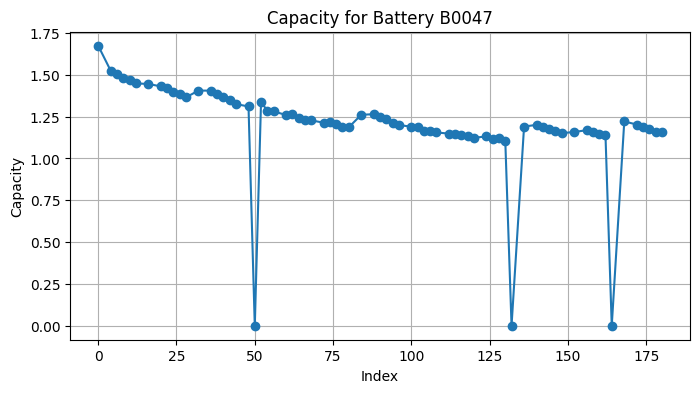

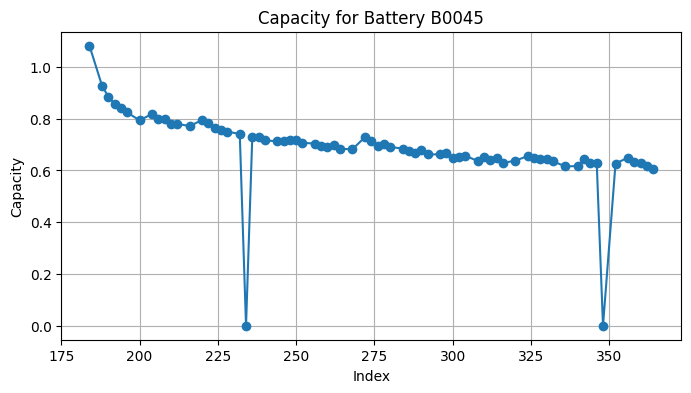

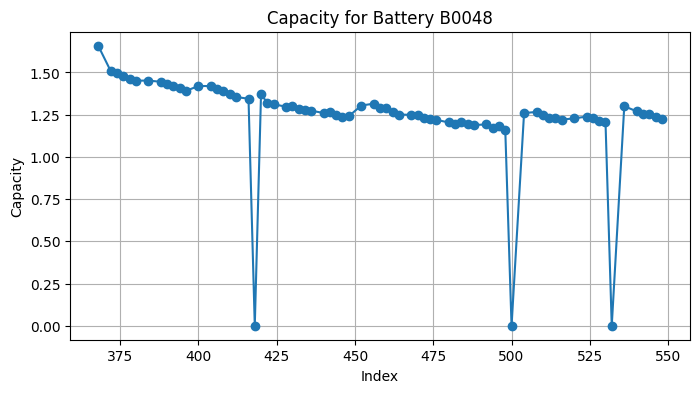

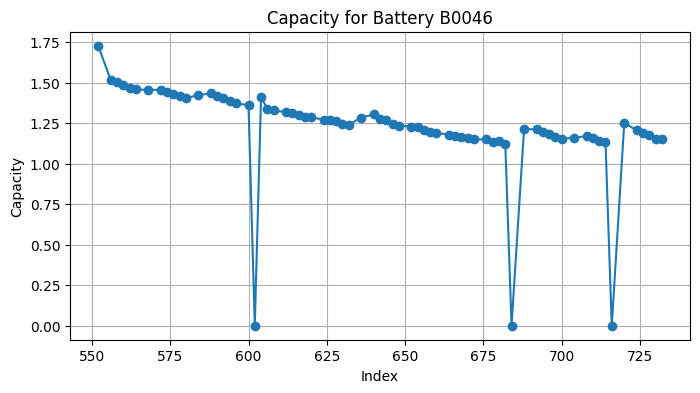

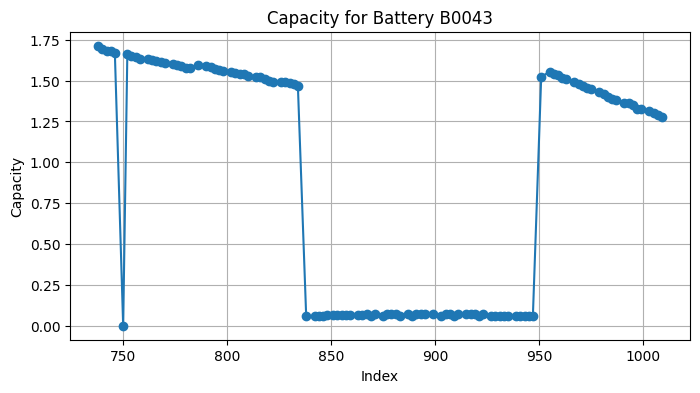

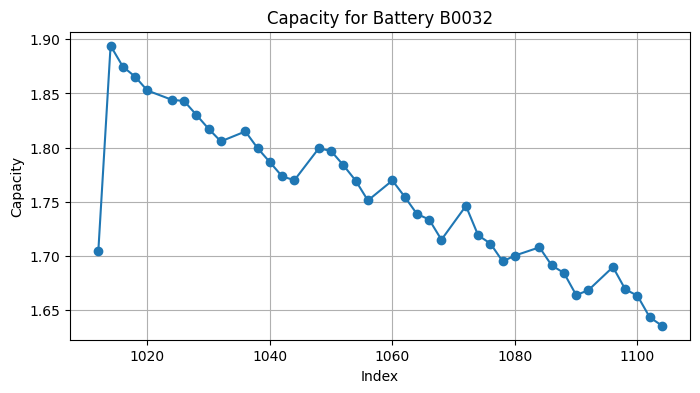

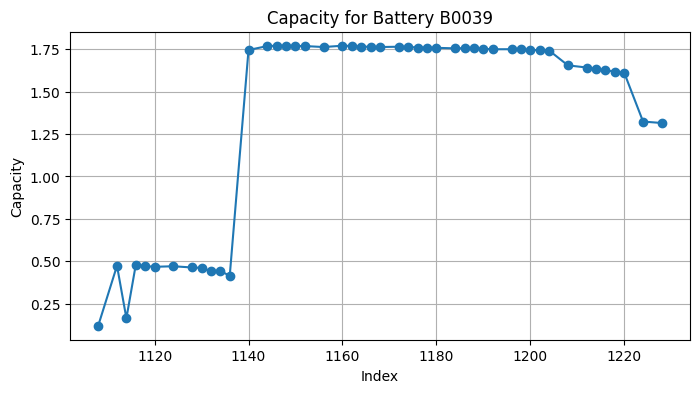

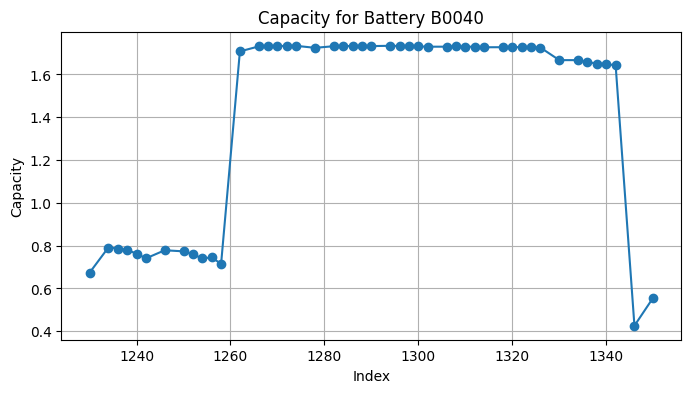

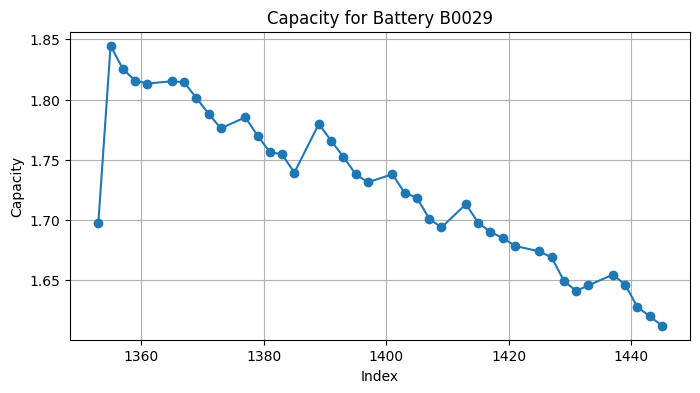

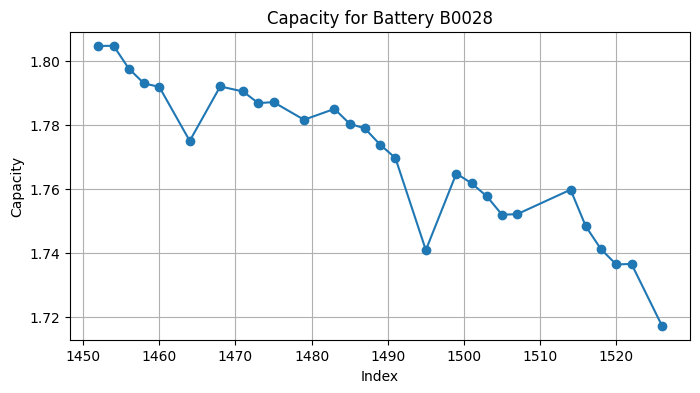

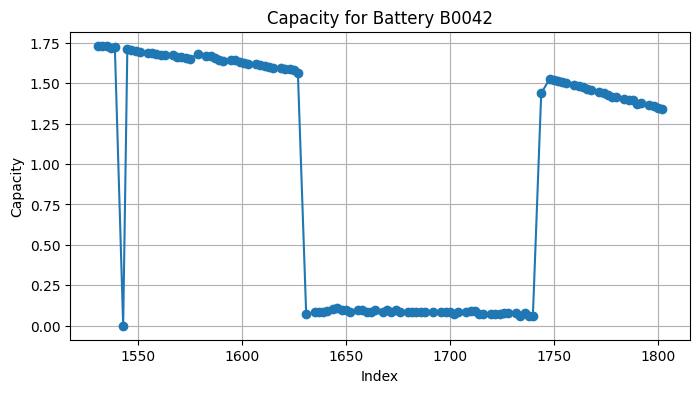

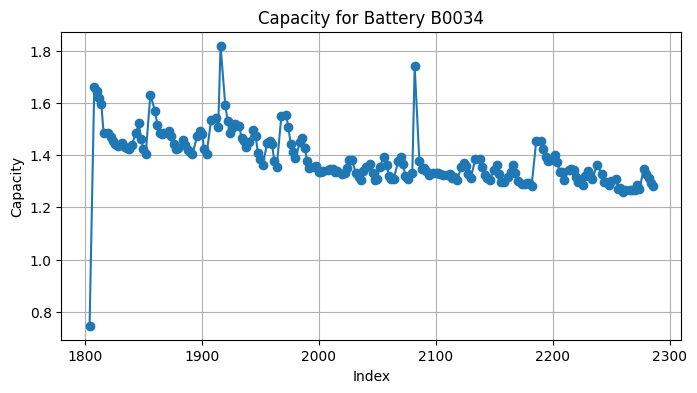

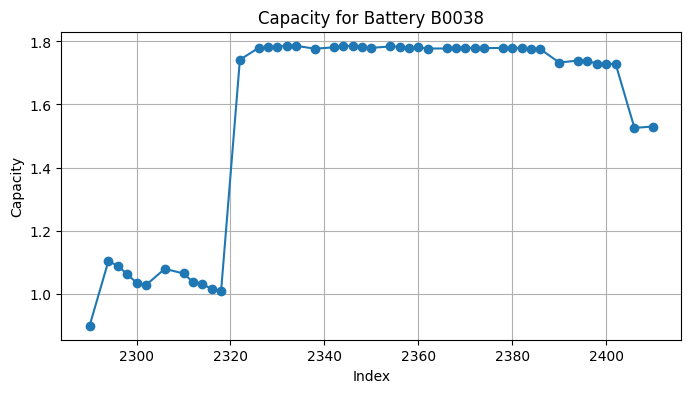

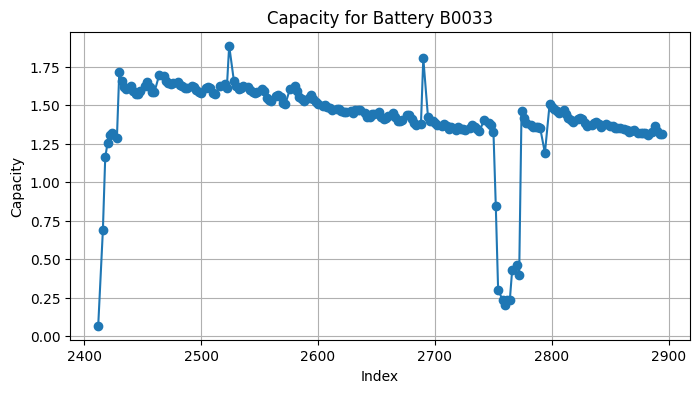

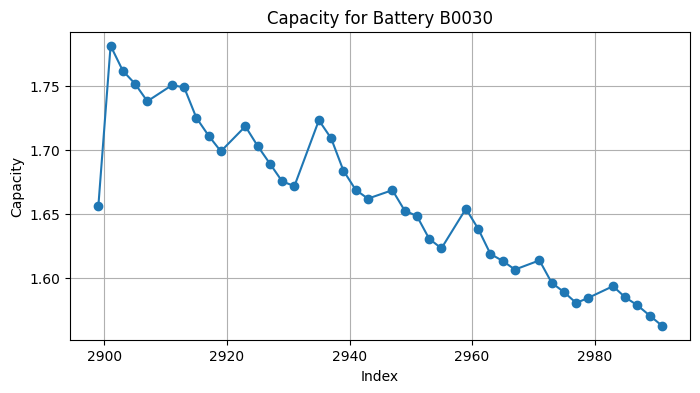

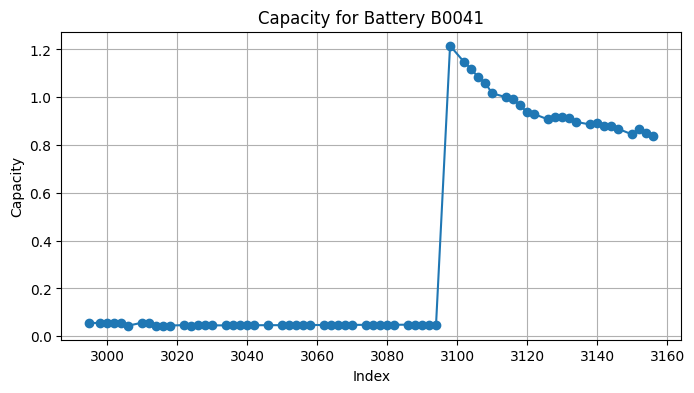

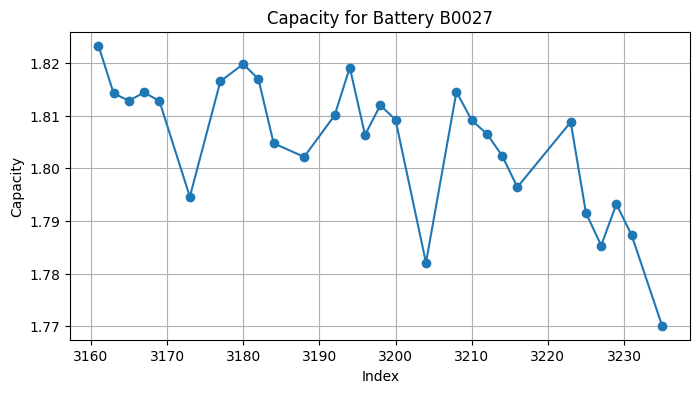

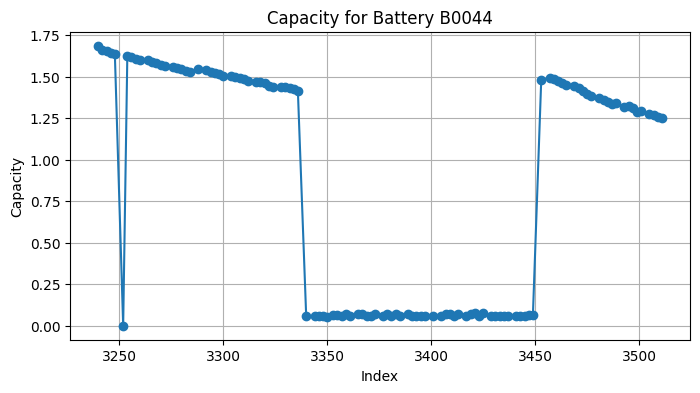

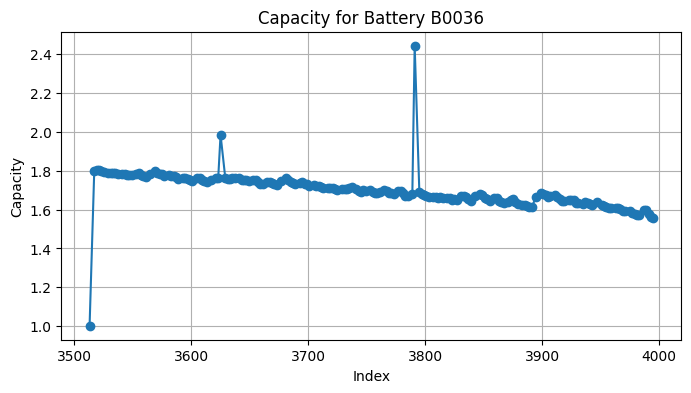

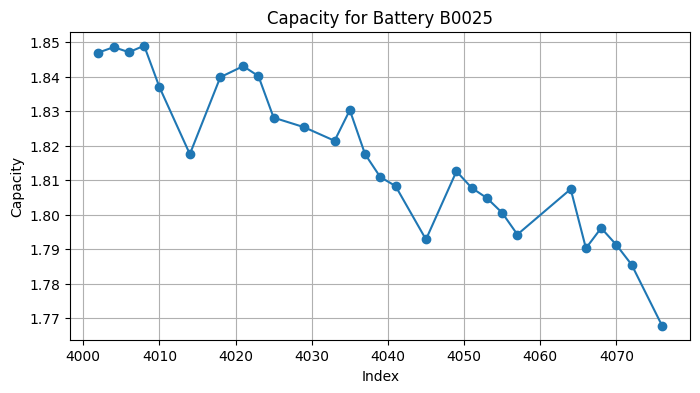

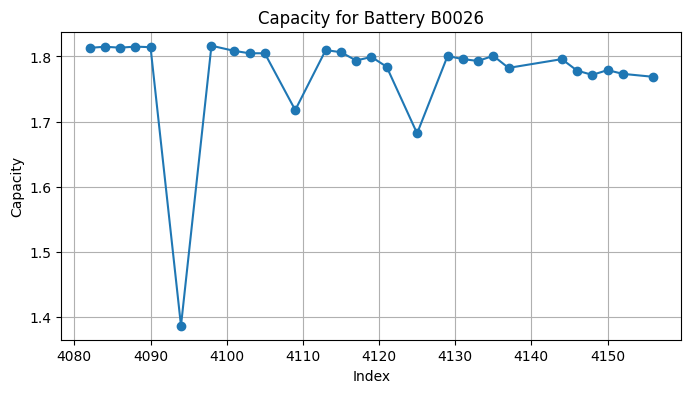

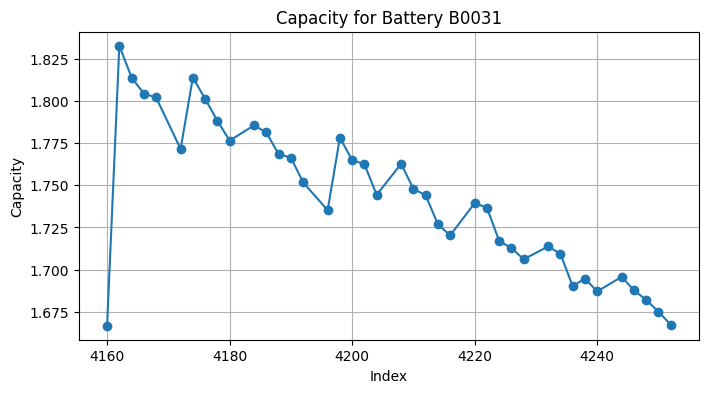

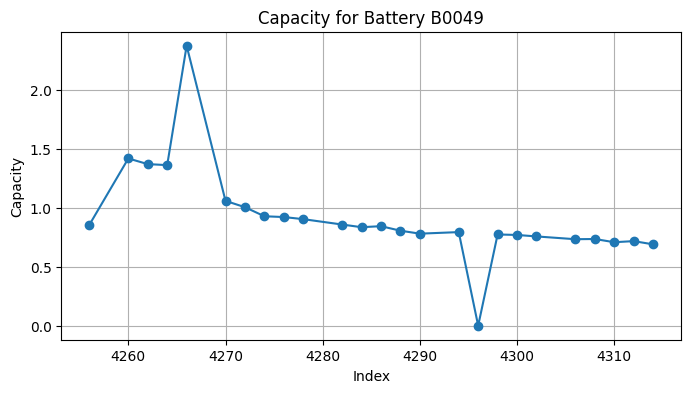

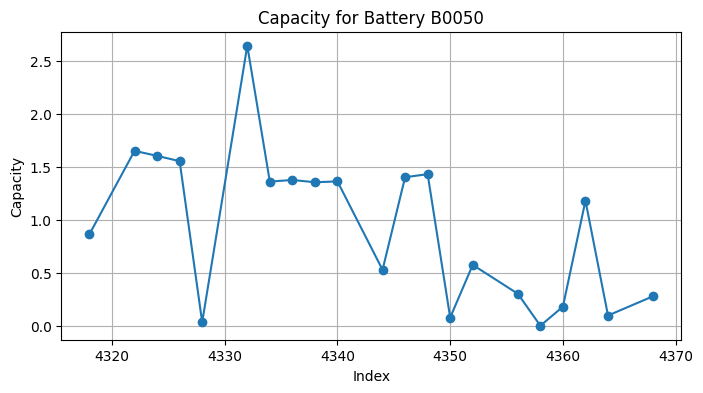

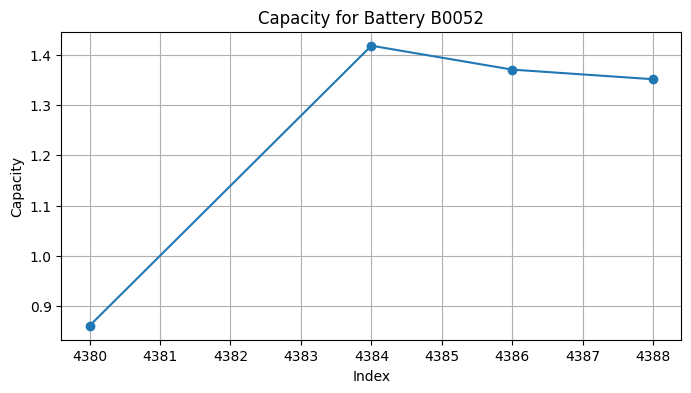

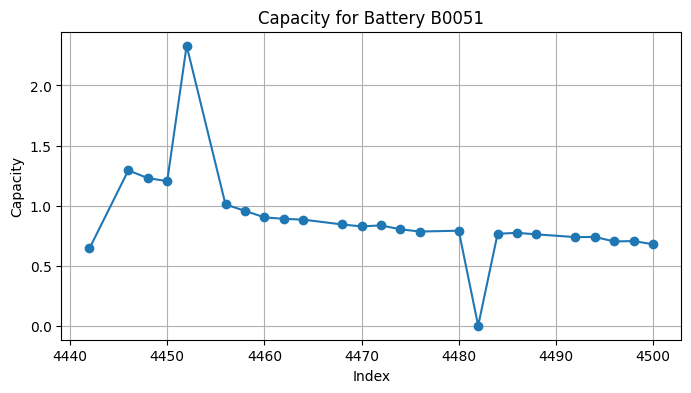

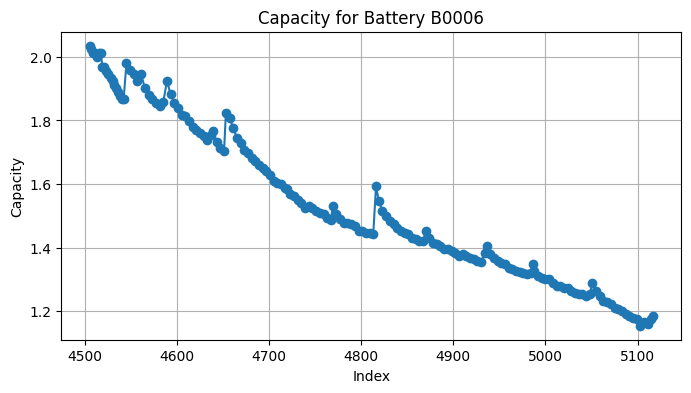

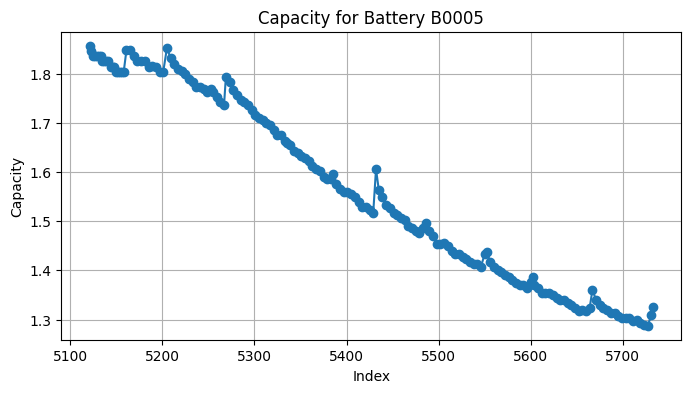

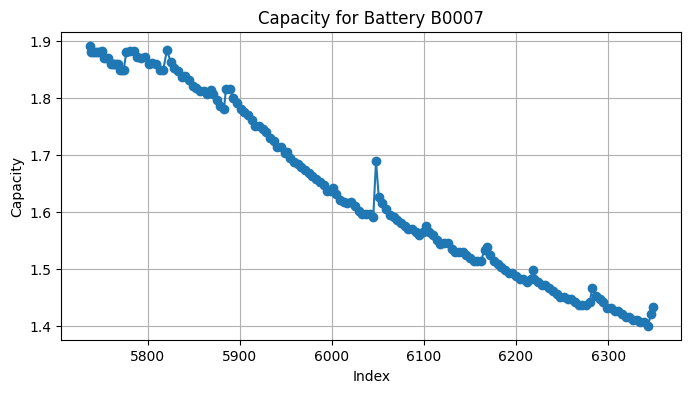

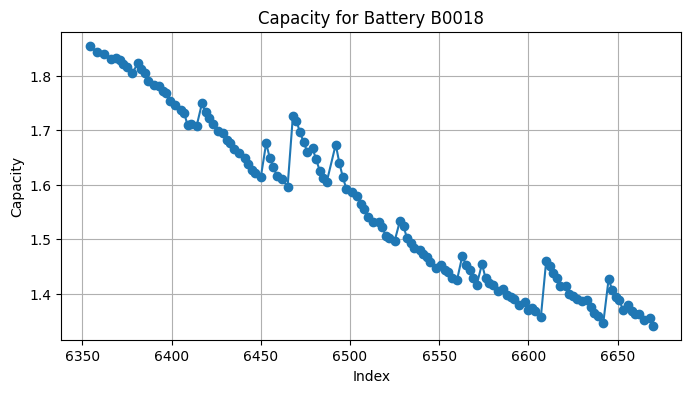

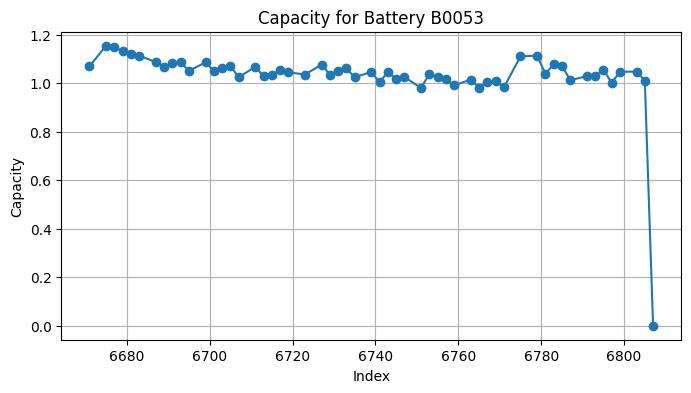

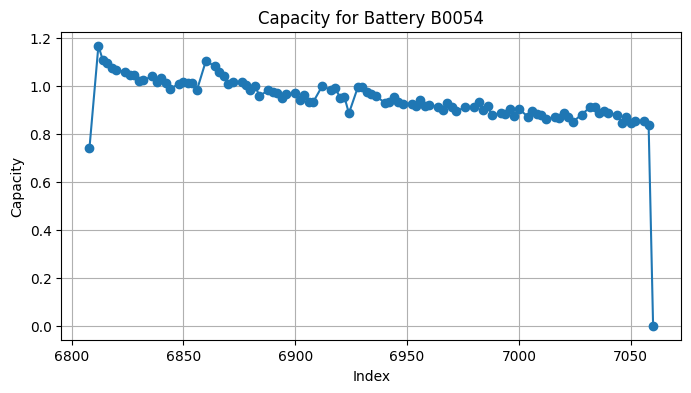

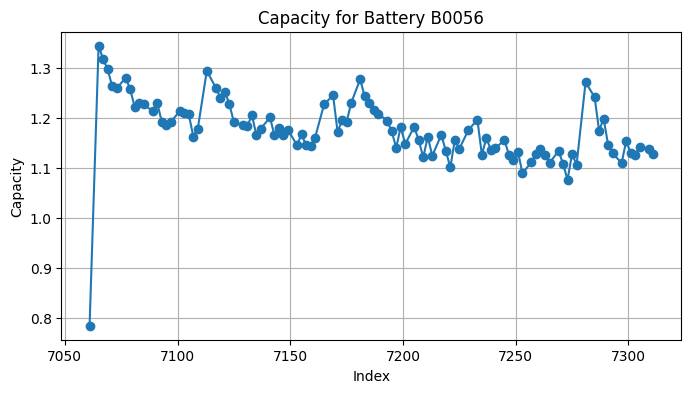

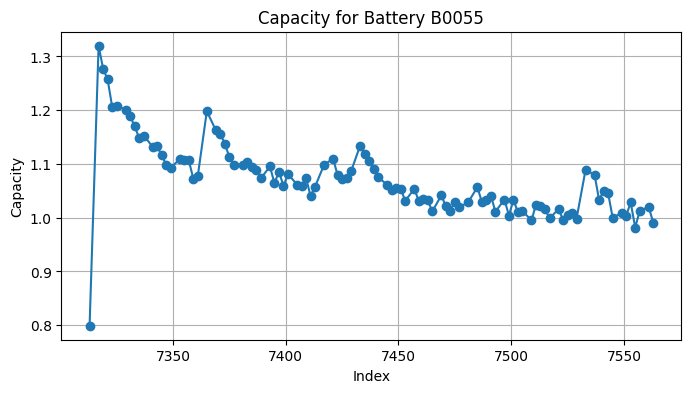

In [47]:
import matplotlib.pyplot as plt

for battery in discharge['battery_id'].unique():
    df_batt = discharge[discharge['battery_id'] == battery]

    plt.figure(figsize=(8,4))
    plt.plot(df_batt.index, df_batt['Capacity'], marker='o')
    plt.title(f"Capacity for Battery {battery}")
    plt.xlabel("Index")
    plt.ylabel("Capacity")
    plt.grid(True)
    plt.show()


In [48]:
discharge[discharge['Capacity']==0]

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity
50,discharge,[2.0100e+03 7.0000e+00 2.9000e+01 2.0000e+00 1...,4,B0047,50,51,00051.csv,0.0
132,discharge,[2010. 8. 7. 11. 26. ...,4,B0047,132,133,00133.csv,0.0
164,discharge,[2010. 8. 13. 11. 16. ...,4,B0047,164,165,00165.csv,0.0
234,discharge,[2.0100e+03 7.0000e+00 2.9000e+01 2.0000e+00 1...,4,B0045,50,235,00235.csv,0.0
348,discharge,[2010. 8. 13. 11. 16. ...,4,B0045,164,349,00349.csv,0.0
418,discharge,[2.0100e+03 7.0000e+00 2.9000e+01 2.0000e+00 1...,4,B0048,50,419,00419.csv,0.0
500,discharge,[2010. 8. 7. 11. 26. ...,4,B0048,132,501,00501.csv,0.0
532,discharge,[2010. 8. 13. 11. 16. ...,4,B0048,164,533,00533.csv,0.0
602,discharge,[2.0100e+03 7.0000e+00 2.9000e+01 2.0000e+00 1...,4,B0046,50,603,00603.csv,0.0
684,discharge,[2010. 8. 7. 11. 26. ...,4,B0046,132,685,00685.csv,0.0


In [49]:
discharge['cycle_no'] = discharge.groupby('battery_id').cumcount() + 1

/tmp/ipykernel_47/284132572.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [50]:
discharge

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,cycle_no
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674305,1
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524366,2
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.508076,3
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.483558,4
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.467139,5
...,...,...,...,...,...,...,...,...,...
7553,discharge,[2010. 9. 29. 19. 50. ...,4,B0055,240,7554,07554.csv,1.028527,98
7555,discharge,[2.01e+03 9.00e+00 2.90e+01 2.30e+01 3.30e+01 ...,4,B0055,242,7556,07556.csv,0.981684,99
7557,discharge,[2010. 9. 30. 3. 15. ...,4,B0055,244,7558,07558.csv,1.012712,100
7561,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.020138,101


In [51]:
discharge = discharge[discharge['Capacity']!=0]

In [52]:
discharge

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,cycle_no
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674305,1
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524366,2
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.508076,3
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.483558,4
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.467139,5
...,...,...,...,...,...,...,...,...,...
7553,discharge,[2010. 9. 29. 19. 50. ...,4,B0055,240,7554,07554.csv,1.028527,98
7555,discharge,[2.01e+03 9.00e+00 2.90e+01 2.30e+01 3.30e+01 ...,4,B0055,242,7556,07556.csv,0.981684,99
7557,discharge,[2010. 9. 30. 3. 15. ...,4,B0055,244,7558,07558.csv,1.012712,100
7561,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.020138,101


In [53]:

numbers_to_keep = [
    47, 45, 48, 46, 32, 29, 28, 34, 33, 30,
    41, 36, 31, 6, 5, 7, 18, 54, 55
]

keep_ids = [f"B{n:04d}" for n in numbers_to_keep]

# Optional: if battery_id has stray spaces/case differences, normalize first
discharge['battery_id'] = discharge['battery_id'].astype(str).str.strip().str.upper()

# ---- 5) Filter to only the selected battery_ids ----
discharge = discharge[discharge['battery_id'].isin(keep_ids)].copy()



/tmp/ipykernel_47/2648752846.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [54]:
discharge

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,cycle_no
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674305,1
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524366,2
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.508076,3
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.483558,4
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.467139,5
...,...,...,...,...,...,...,...,...,...
7553,discharge,[2010. 9. 29. 19. 50. ...,4,B0055,240,7554,07554.csv,1.028527,98
7555,discharge,[2.01e+03 9.00e+00 2.90e+01 2.30e+01 3.30e+01 ...,4,B0055,242,7556,07556.csv,0.981684,99
7557,discharge,[2010. 9. 30. 3. 15. ...,4,B0055,244,7558,07558.csv,1.012712,100
7561,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.020138,101


In [55]:
discharge = discharge.reset_index(drop=True)

In [56]:
discharge.to_csv("discharge.csv")

In [57]:
import pandas as pd
from pathlib import Path
import shutil

source_dir = Path("/kaggle/input/nasa-battery-dataset/cleaned_dataset/data")

dest_dir = Path("/kaggle/working/files")

dest_dir.mkdir(parents=True, exist_ok=True)

required_col = "filename"
if required_col not in discharge.columns:
    raise ValueError(
        f"Column '{required_col}' not found in the DataFrame. "
        f"Available columns: {list(discharge.columns)}"
    )

# ---------- GET FILENAMES FROM DISCHARGE DATA ----------
filenames = (
    discharge[required_col]
    .dropna()
    .astype(str)
    .str.strip()
    .tolist()
)

# Deduplicate while preserving order
filenames = list(dict.fromkeys(filenames))

# ---------- COPY ONLY THESE FILES ----------
copied, missing = [], []
for name in filenames:
    src_path = Path(name)

    # If the filename is relative (no parent folder), look inside source_dir
    if not src_path.is_absolute():
        src_path = source_dir / src_path

    if src_path.exists() and src_path.is_file():
        dest_path = dest_dir / src_path.name  # copy just the basename
        shutil.copy2(src_path, dest_path)     # preserves metadata
        copied.append(str(dest_path))
    else:
        missing.append(str(src_path))

print(f"Copied {len(copied)} file(s) to: {dest_dir}")
if missing:
    print(f"WARNING: {len(missing)} file(s) not found in source_dir:")
    for m in missing[:20]:
        print(" -", m)
    if len(missing) > 20:
        print(" ... (truncated)")


Copied 1963 file(s) to: /kaggle/working/files


In [58]:
def compute_soc_for_cycle(
    df: pd.DataFrame,
    op_type: str,
    time_col: str = "Time",
    current_col: str = "Current_measured",
    current_noise_threshold: float = 1e-3,
    known_capacity_Ah: float = None,
):
    """
    Compute State of Charge (SoC) for a single cycle, depending on operation type.

    op_type:
      - "discharge": SoC goes from ~1 -> 0 using discharge current
      - "charge"   : SoC goes from ~0 -> 1 using charge current
      - "impedance": no time-series current; returns SoC = NaN for all rows

    For charge / discharge:
      - Uses coulomb counting: I * dt / 3600 [Ah]
      - If known_capacity_Ah is None, capacity is estimated from the cycle itself
        (sum of Ah over the active sign).

    Returns:
      df_out: original df + added columns:
          - delta_t      : time step (s)
          - I_clean      : denoised current
          - SoC          : [0, 1]
          - SoC_percent  : [0, 100]
      capacity_Ah: capacity used for normalization
    """
    op_type = str(op_type).lower()

    # -----------------------------
    # Impedance: no waveform -> NaN SoC
    # -----------------------------
    if op_type == "impedance":
        df = df.copy()
        df["SoC"] = np.nan
        df["SoC_percent"] = np.nan
        return df, np.nan

    # -----------------------------
    # Charge / Discharge
    # -----------------------------
    df = df.copy()
    df = df.sort_values(time_col).reset_index(drop=True)

    # 1) Time step
    df["delta_t"] = df[time_col].diff().fillna(0.0)  # seconds

    # 2) Clean current (remove tiny noise)
    I = df[current_col].astype(float).values
    I_clean = np.where(np.abs(I) < current_noise_threshold, 0.0, I)
    df["I_clean"] = I_clean

    # Prepare arrays for integration
    dt = df["delta_t"].values

    if op_type == "discharge":
        # Negative current = discharge
        I_dis = np.clip(I_clean, None, 0.0)  # <= 0
        delta_Ah_dis = -I_dis * dt / 3600.0   # positive Ah
        df["delta_Ah_dis"] = delta_Ah_dis

        # Estimate capacity if not given
        if known_capacity_Ah is None:
            capacity_Ah = delta_Ah_dis.sum()
        else:
            capacity_Ah = float(known_capacity_Ah)

        if capacity_Ah <= 0:
            # Fallback to avoid division by zero
            df["SoC"] = np.nan
            df["SoC_percent"] = np.nan
            return df, np.nan

        df["cum_Ah_dis"] = delta_Ah_dis.cumsum()
        # SoC ~ 1 at start, 0 at end of full discharge
        df["SoC"] = 1.0 - df["cum_Ah_dis"] / capacity_Ah

    elif op_type == "charge":
        # Positive current = charge
        I_chg = np.clip(I_clean, 0.0, None)  # >= 0
        delta_Ah_chg = I_chg * dt / 3600.0   # positive Ah
        df["delta_Ah_chg"] = delta_Ah_chg

        # Estimate capacity if not given
        if known_capacity_Ah is None:
            capacity_Ah = delta_Ah_chg.sum()
        else:
            capacity_Ah = float(known_capacity_Ah)

        if capacity_Ah <= 0:
            # Fallback to avoid division by zero
            df["SoC"] = np.nan
            df["SoC_percent"] = np.nan
            return df, np.nan

        df["cum_Ah_chg"] = delta_Ah_chg.cumsum()
        # SoC ~ 0 at start, 1 at end of full charge
        df["SoC"] = df["cum_Ah_chg"] / capacity_Ah

    else:
        # Unknown type -> no SoC
        df["SoC"] = np.nan
        df["SoC_percent"] = np.nan
        return df, np.nan

    # Clip numerical noise
    df["SoC"] = df["SoC"].clip(0.0, 1.0)
    df["SoC_percent"] = df["SoC"] * 100.0

    return df, capacity_Ah

In [59]:
# ---------- Paths: adjust for your environment ----------
METADATA_PATH = "/kaggle/working/discharge.csv"
DATA_DIR      = "/kaggle/working/files/"
OUTPUT_DIR    = "/kaggle/working/files/SoC"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load metadata so we know operation type + filename
meta = pd.read_csv(METADATA_PATH)

# Ensure columns exist
if "filename" not in meta.columns or "type" not in meta.columns:
    raise ValueError("metadata.csv must contain 'filename' and 'type' columns.")

meta["filename"] = meta["filename"].astype(str)
meta["type"] = meta["type"].astype(str)

for i, row in meta.iterrows():
    fname = row["filename"]
    op_type = row["type"]  # "charge", "discharge", or "impedance"

    in_path = os.path.join(DATA_DIR, fname)
    out_path = os.path.join(OUTPUT_DIR, fname)

    if not os.path.isfile(in_path):
        print(f"[WARN] {fname}: file not found, skipping.")
        continue

    try:
        df = pd.read_csv(in_path)
    except Exception as e:
        print(f"[WARN] {fname}: error reading file ({e}), skipping.")
        continue

    # For charge/discharge we need Time + Current_measured
    if op_type.lower() in ["charge", "discharge"]:
        required_cols = ["Time", "Current_measured"]
        if not all(c in df.columns for c in required_cols):
            print(f"[WARN] {fname}: missing {required_cols}, cannot compute SoC, skipping.")
            continue

        df_soc, cap_Ah = compute_soc_for_cycle(
            df,
            op_type=op_type,
            time_col="Time",
            current_col="Current_measured",
            # known_capacity_Ah=2.0  # <- uncomment to force rated capacity
        )

    else:
        # Impedance: no waveform; function will create NaN SoC
        df_soc, cap_Ah = compute_soc_for_cycle(df, op_type=op_type)

    # Save with SoC column
    df_soc.to_csv(out_path, index=False)

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1} / {len(meta)} files...")

print("Done. Files with SoC are in:", OUTPUT_DIR)

Processed 100 / 1963 files...
Processed 200 / 1963 files...
Processed 300 / 1963 files...
Processed 400 / 1963 files...
Processed 500 / 1963 files...
Processed 600 / 1963 files...
Processed 700 / 1963 files...
Processed 800 / 1963 files...
Processed 900 / 1963 files...
Processed 1000 / 1963 files...
Processed 1100 / 1963 files...
Processed 1200 / 1963 files...
Processed 1300 / 1963 files...
Processed 1400 / 1963 files...
Processed 1500 / 1963 files...
Processed 1600 / 1963 files...
Processed 1700 / 1963 files...
Processed 1800 / 1963 files...
Processed 1900 / 1963 files...
Done. Files with SoC are in: /kaggle/working/files/SoC


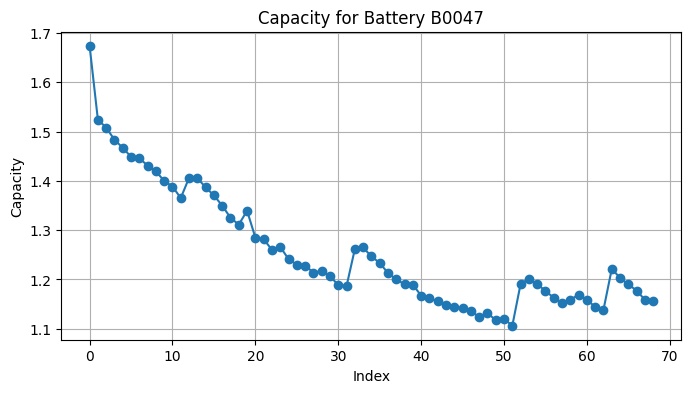

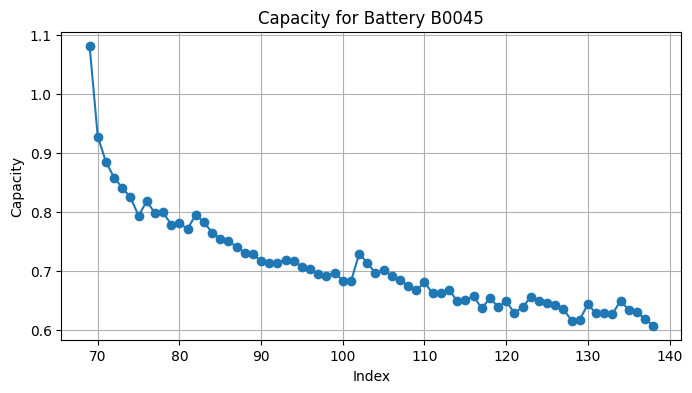

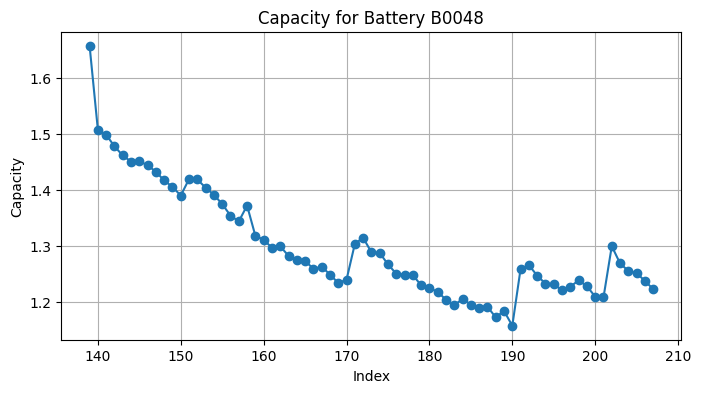

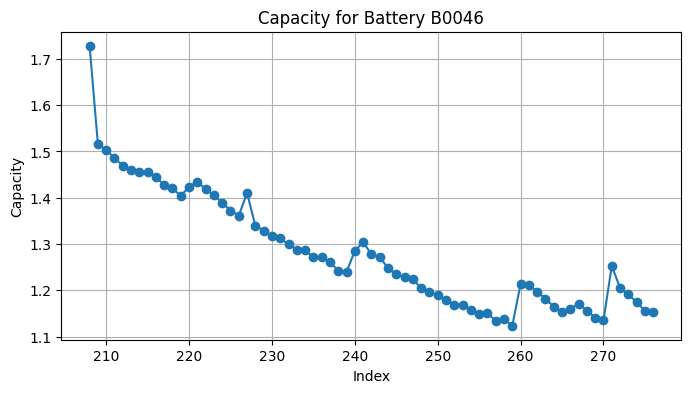

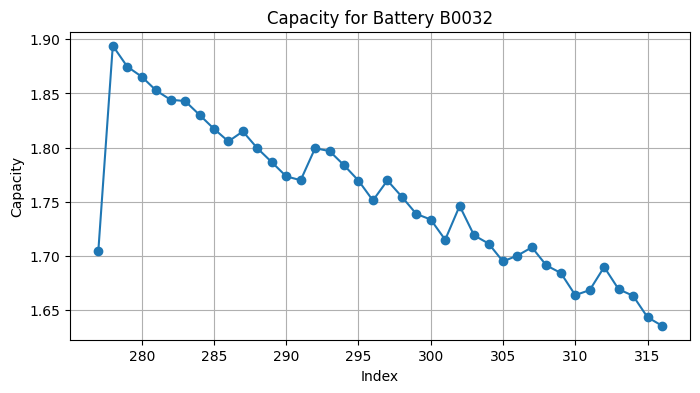

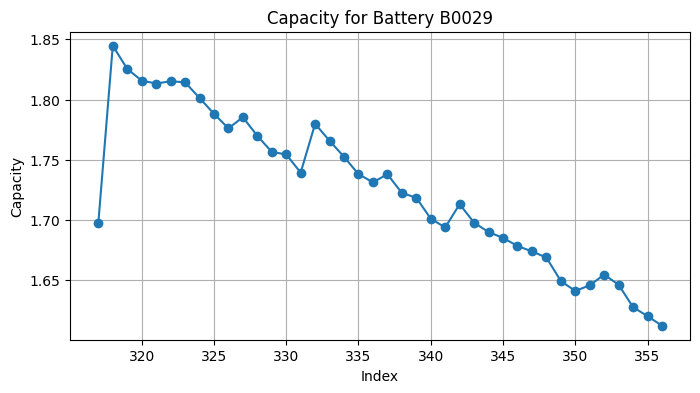

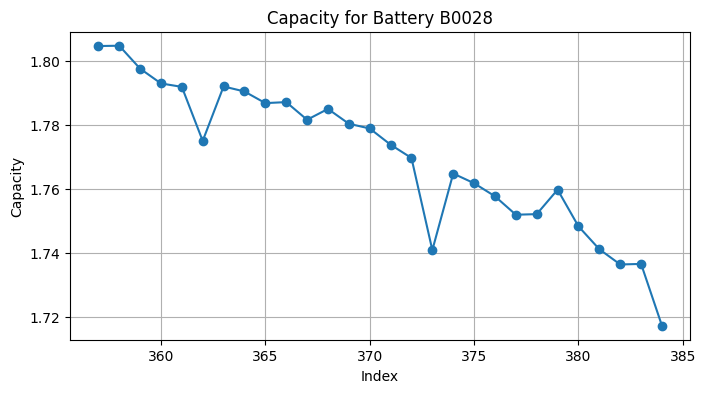

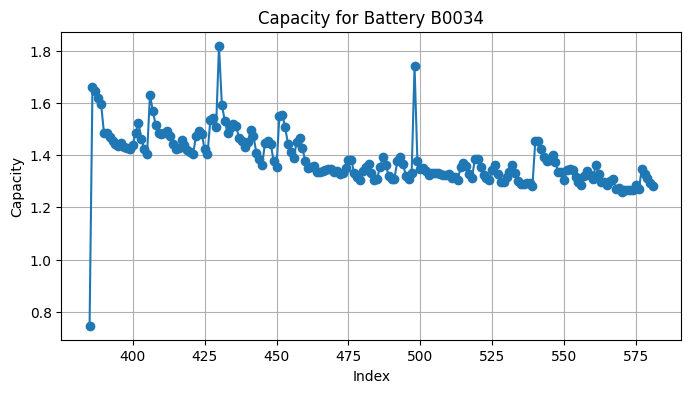

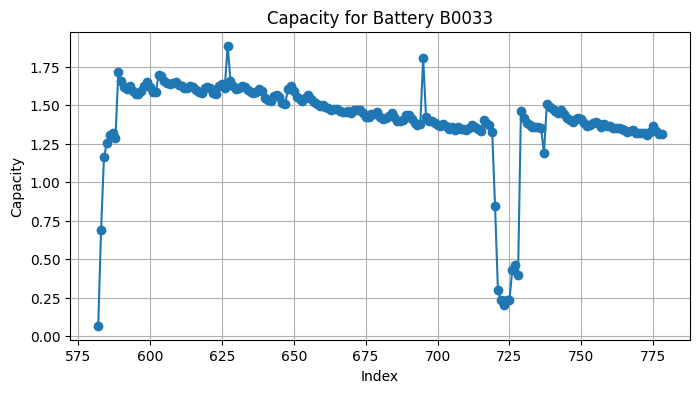

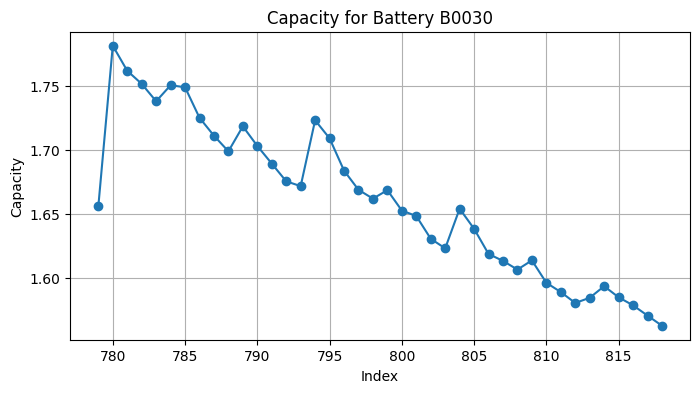

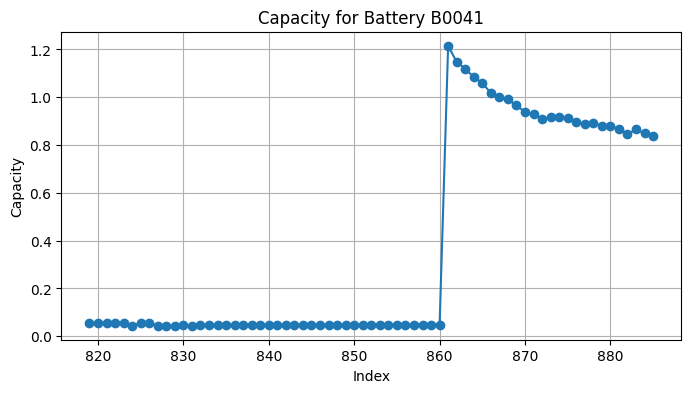

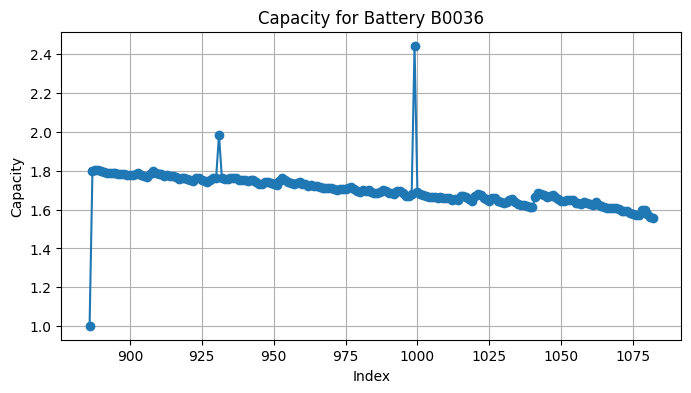

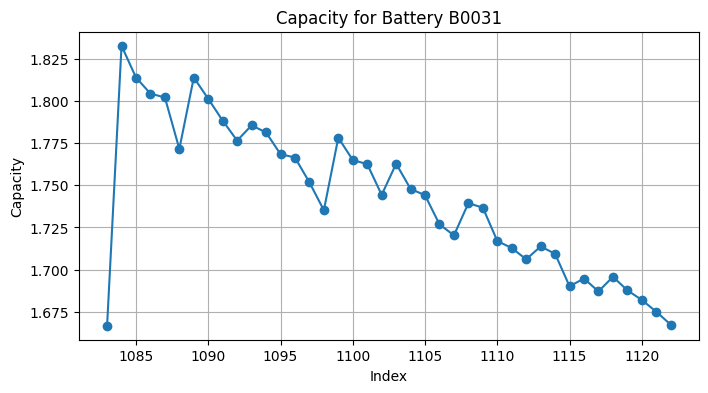

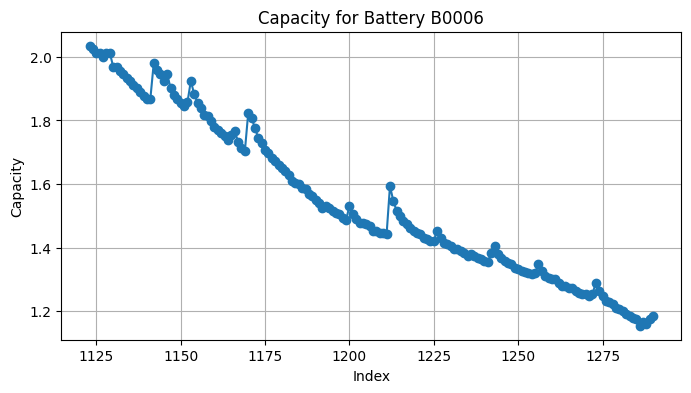

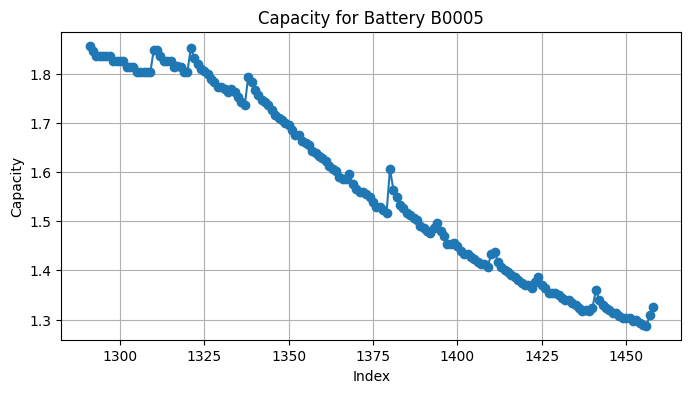

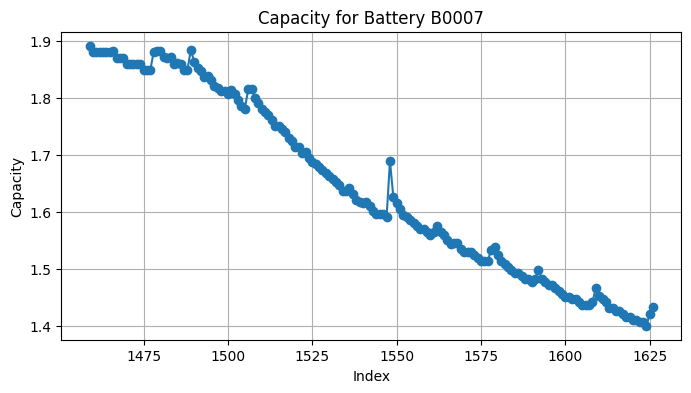

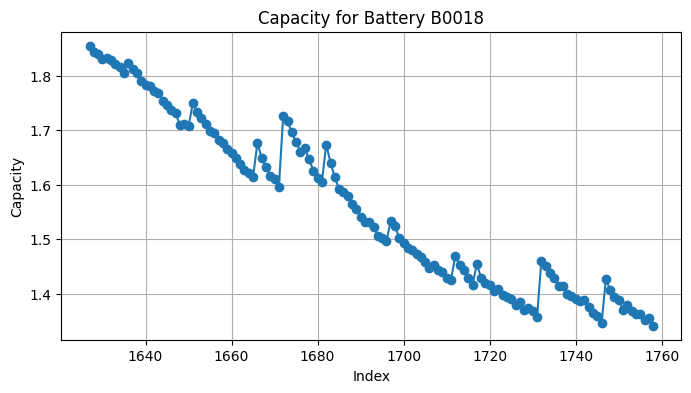

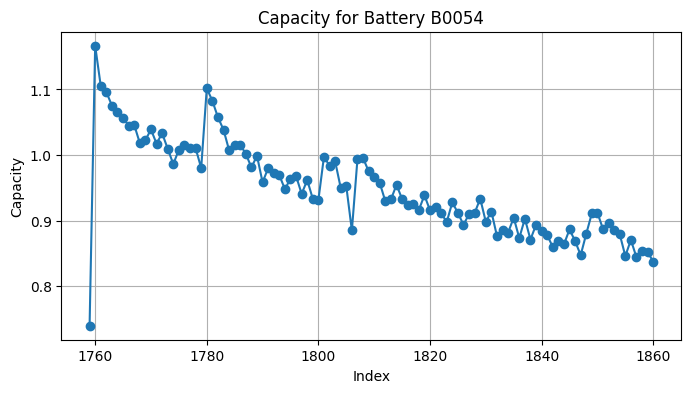

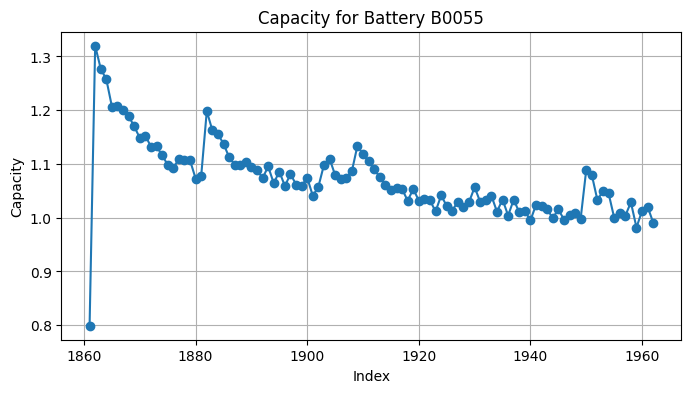

In [60]:
import matplotlib.pyplot as plt

for battery in discharge['battery_id'].unique():
    df_batt = discharge[discharge['battery_id'] == battery]

    plt.figure(figsize=(8,4))
    plt.plot(df_batt.index, df_batt['Capacity'], marker='o')
    plt.title(f"Capacity for Battery {battery}")
    plt.xlabel("Index")
    plt.ylabel("Capacity")
    plt.grid(True)
    plt.show()

In [61]:
discharge['battery_id'].value_counts()

battery_id
B0036    197
B0034    197
B0033    197
B0007    168
B0005    168
B0006    168
B0018    132
B0055    102
B0054    102
B0045     70
B0047     69
B0046     69
B0048     69
B0041     67
B0031     40
B0029     40
B0032     40
B0030     40
B0028     28
Name: count, dtype: int64

In [62]:
discharge

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,cycle_no
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674305,1
1,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524366,2
2,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.508076,3
3,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.483558,4
4,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.467139,5
...,...,...,...,...,...,...,...,...,...
1958,discharge,[2010. 9. 29. 19. 50. ...,4,B0055,240,7554,07554.csv,1.028527,98
1959,discharge,[2.01e+03 9.00e+00 2.90e+01 2.30e+01 3.30e+01 ...,4,B0055,242,7556,07556.csv,0.981684,99
1960,discharge,[2010. 9. 30. 3. 15. ...,4,B0055,244,7558,07558.csv,1.012712,100
1961,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.020138,101


In [63]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# 1. Function to remove capacity outliers per battery_id
# -------------------------------------------------------------------
def remove_capacity_outliers(df, window=5, z_thresh=3.5):
    """
    Remove local/global capacity outliers per battery_id from `df`.
    Uses rolling median + MAD-based robust z-score on Capacity.

    Requires columns: ['battery_id', 'cycle_no', 'Capacity']
    """
    # Sort in time/cycle order
    df = df.sort_values(['battery_id', 'cycle_no']).copy()

    def clean_one_battery(group: pd.DataFrame) -> pd.DataFrame:
        cap = group['Capacity'].astype(float)

        # Local trend: rolling median
        med = cap.rolling(window=window, center=True, min_periods=1).median()

        # Residuals from local trend
        resid = cap - med

        # Robust spread: Median Absolute Deviation (MAD)
        mad = np.median(np.abs(resid - np.median(resid)))

        # If essentially no variation, keep group as-is
        if mad == 0 or np.isnan(mad):
            return group

        # Robust z-score
        robust_z = 0.6745 * resid / mad

        # Filter out strong outliers (both maxima and minima)
        mask = robust_z.abs() <= z_thresh
        return group[mask]

    cleaned = df.groupby('battery_id', group_keys=False).apply(clean_one_battery)
    cleaned = cleaned.reset_index(drop=True)
    return cleaned


# -------------------------------------------------------------------
# 2. Function to compute initial capacities per battery_id (optional)
# -------------------------------------------------------------------
def compute_start_capacities(cleaned_df: pd.DataFrame):
    """
    Compute "start" capacity for each battery_id after cleaning.

    Returns:
      - start_first: first (earliest cycle) capacity for each battery
      - start_max: max capacity for each battery
    """
    cleaned_df = cleaned_df.sort_values(['battery_id', 'cycle_no'])

    # First surviving cycle per battery
    start_first = (
        cleaned_df.groupby('battery_id')
                  .first()['Capacity']
                  .rename('start_capacity_first')
    )

    # Max capacity per battery
    start_max = (
        cleaned_df.groupby('battery_id')['Capacity']
                  .max()
                  .rename('start_capacity_max')
    )

    return start_first, start_max


# -------------------------------------------------------------------
# 3. Wrapper: read CSV, clean, add max Capacity column, write CSV
# -------------------------------------------------------------------
def process_discharge_csv(input_csv, output_csv, window=5, z_thresh=3.5):
    """
    - Reads `input_csv` (must have: battery_id, cycle_no, Capacity)
    - Removes Capacity outliers per battery_id
    - Computes the highest cleaned Capacity per battery_id
    - Adds that value as a new column 'max_capacity_per_battery'
      for every row of that battery in the cleaned data
    - Writes the cleaned data + new column to `output_csv`

    Returns:
        cleaned_df_with_max (pd.DataFrame)
    """
    # Read original discharge data
    discharge = pd.read_csv(input_csv)

    # Clean outliers
    discharge_clean = remove_capacity_outliers(discharge, window=window, z_thresh=z_thresh)

    # Highest cleaned Capacity per battery_id
    max_cap_per_batt = (
        discharge_clean
        .groupby('battery_id')['Capacity']
        .max()
        .rename('max_capacity_per_battery')
    )

    # Merge back into cleaned dataframe as a new column
    discharge_clean = discharge_clean.merge(
        max_cap_per_batt,
        on='battery_id',
        how='left'
    )

    # Save to CSV
    discharge_clean.to_csv(output_csv, index=False)

    return discharge_clean


# -------------------------------------------------------------------
# Example usage
# -------------------------------------------------------------------
# This will read discharge.csv, process it, and write discharge_with_max.csv
# You can set output_csv="discharge.csv" if you want to overwrite the original.
if __name__ == "__main__":
    cleaned = process_discharge_csv(
        input_csv="discharge.csv",
        output_csv="discharge_with_max.csv",
        window=5,
        z_thresh=3.5
    )
    print(cleaned.head())


   Unnamed: 0       type                                         start_time  \
0        1291  discharge  [2.0080e+03 4.0000e+00 2.0000e+00 1.5000e+01 2...   
1        1292  discharge  [2.0080e+03 4.0000e+00 2.0000e+00 1.9000e+01 4...   
2        1293  discharge  [2.008e+03 4.000e+00 3.000e+00 0.000e+00 1.000...   
3        1294  discharge  [2008.       4.       3.       4.      16.    ...   
4        1295  discharge  [2008.       4.       3.       8.      33.    ...   

   ambient_temperature battery_id  test_id   uid   filename  Capacity  \
0                   24      B0005        1  5122  05122.csv  1.856487   
1                   24      B0005        3  5124  05124.csv  1.846327   
2                   24      B0005        5  5126  05126.csv  1.835349   
3                   24      B0005        7  5128  05128.csv  1.835263   
4                   24      B0005        9  5130  05130.csv  1.834646   

   cycle_no  max_capacity_per_battery  
0         1                  1.856487  
1     

/tmp/ipykernel_47/3225652976.py:40: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [64]:
cleaned

,Unnamed: 0,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,cycle_no,max_capacity_per_battery
0,1291,discharge,[2.0080e+03 4.0000e+00 2.0000e+00 1.5000e+01 2...,24,B0005,1,5122,05122.csv,1.856487,1,1.856487
1,1292,discharge,[2.0080e+03 4.0000e+00 2.0000e+00 1.9000e+01 4...,24,B0005,3,5124,05124.csv,1.846327,2,1.856487
2,1293,discharge,[2.008e+03 4.000e+00 3.000e+00 0.000e+00 1.000...,24,B0005,5,5126,05126.csv,1.835349,3,1.856487
3,1294,discharge,[2008. 4. 3. 4. 16. ...,24,B0005,7,5128,05128.csv,1.835263,4,1.856487
4,1295,discharge,[2008. 4. 3. 8. 33. ...,24,B0005,9,5130,05130.csv,1.834646,5,1.856487
...,...,...,...,...,...,...,...,...,...,...,...
1768,1957,discharge,[2010. 9. 29. 16. 8. ...,4,B0055,238,7552,07552.csv,1.003655,97,1.276983
1769,1958,discharge,[2010. 9. 29. 19. 50. ...,4,B0055,240,7554,07554.csv,1.028527,98,1.276983
1770,1960,discharge,[2010. 9. 30. 3. 15. ...,4,B0055,244,7558,07558.csv,1.012712,100,1.276983
1771,1961,discharge,[2010. 9. 30. 8. 8. ...,4,B0055,248,7562,07562.csv,1.020138,101,1.276983


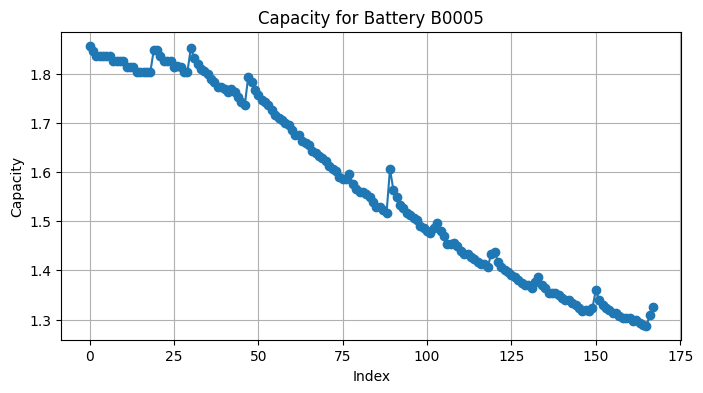

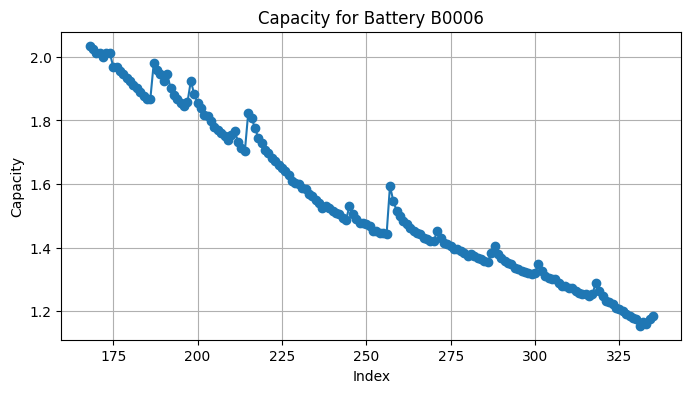

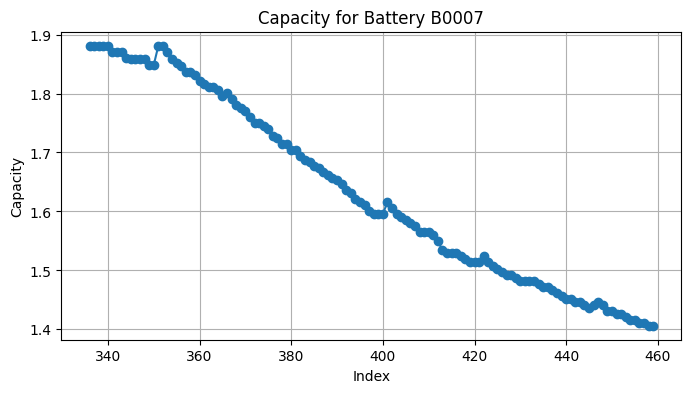

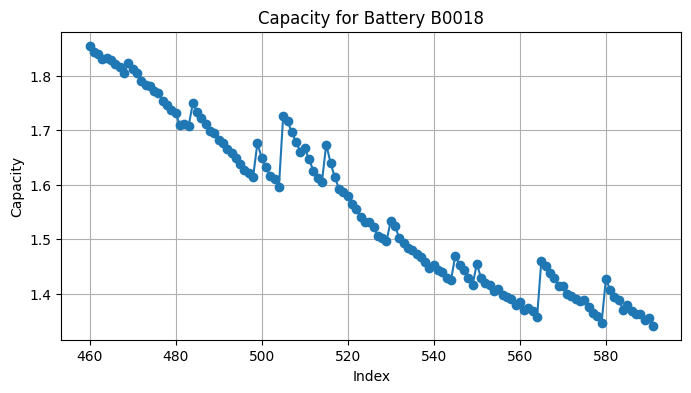

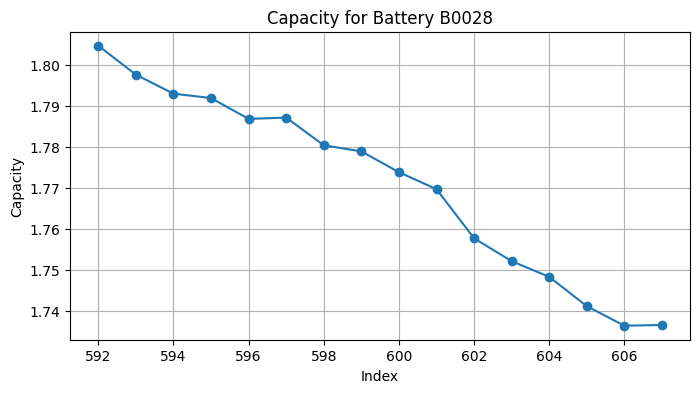

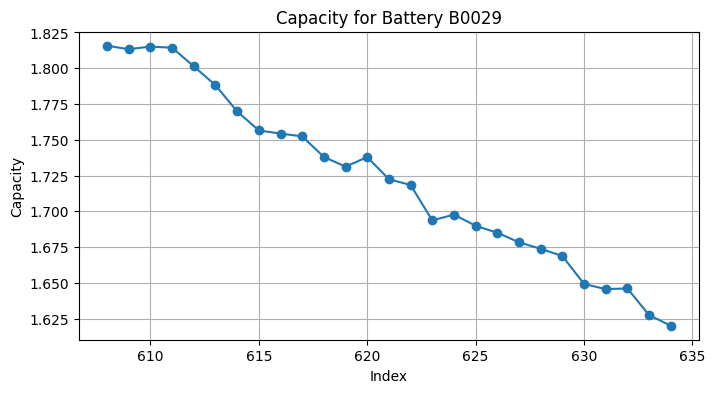

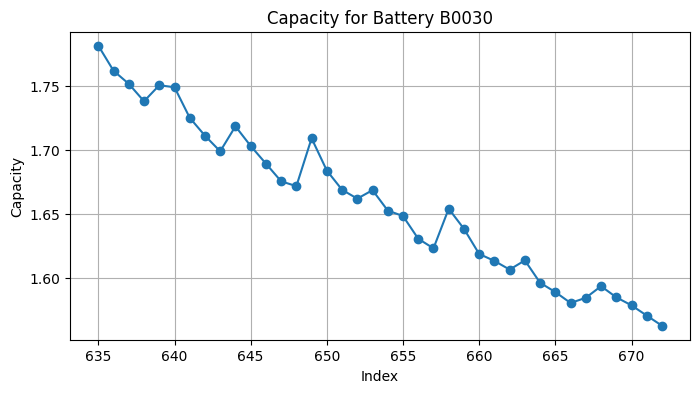

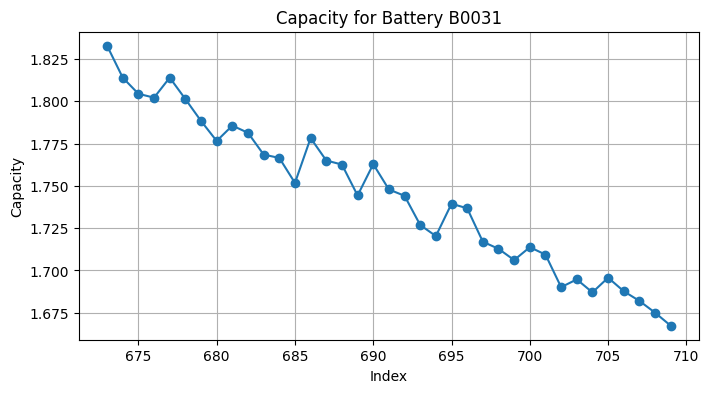

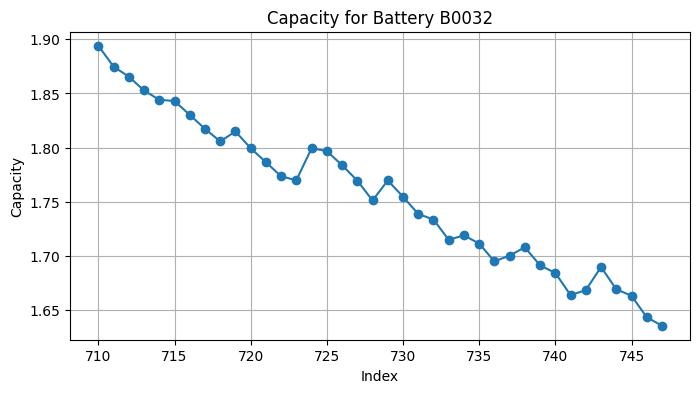

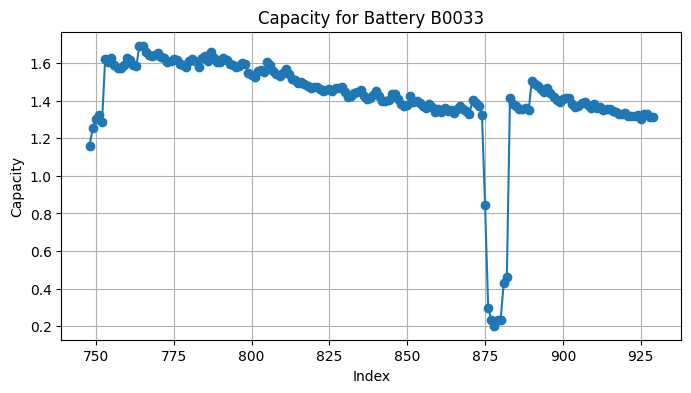

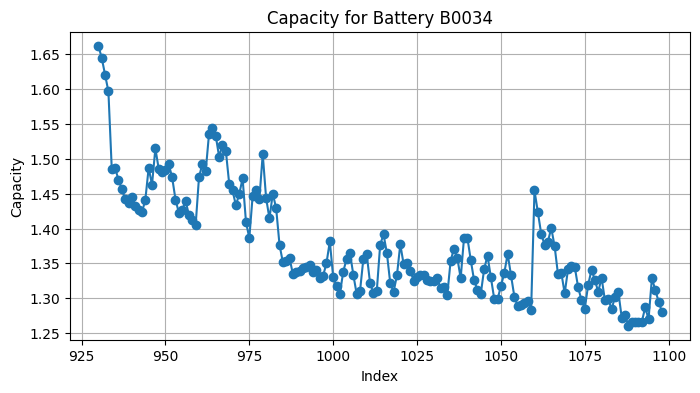

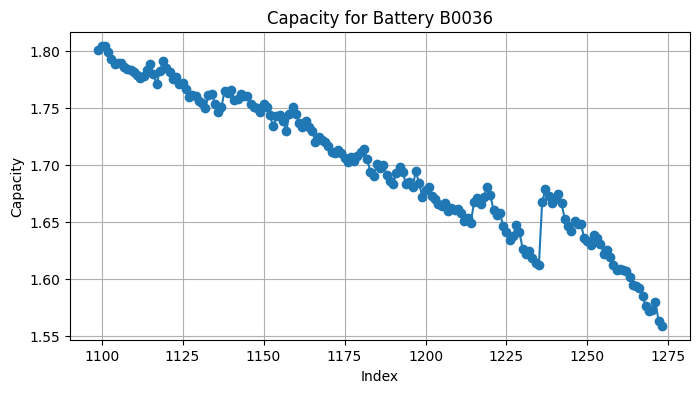

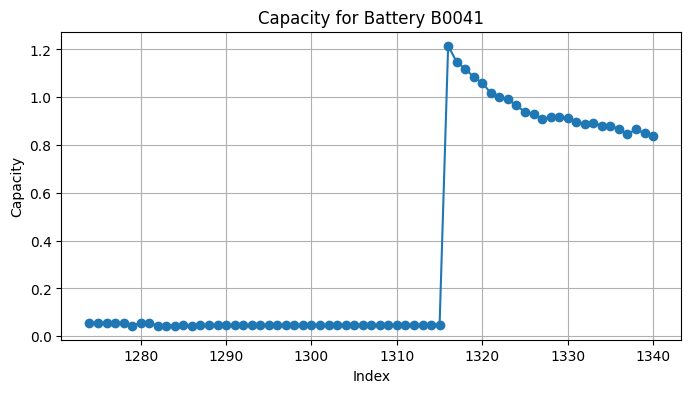

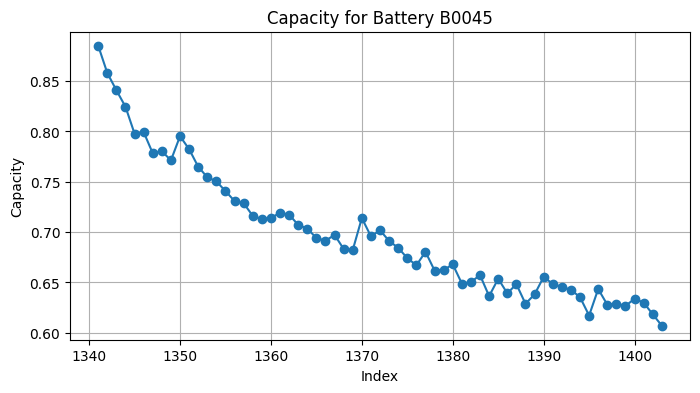

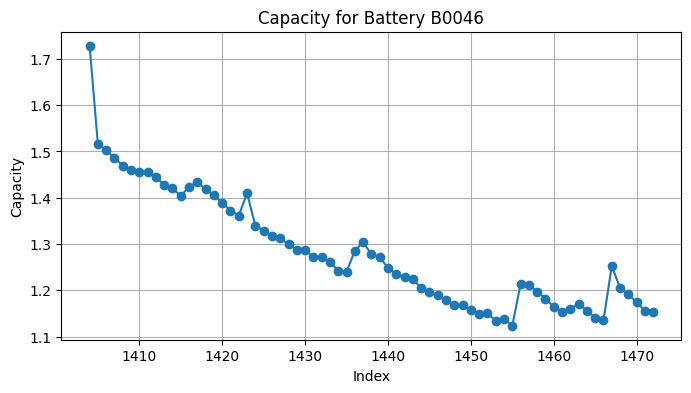

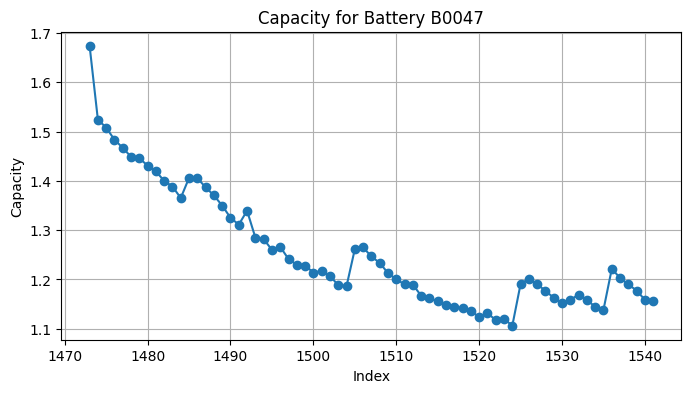

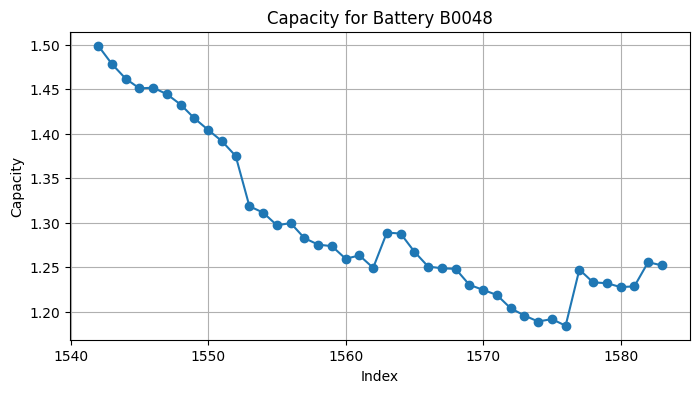

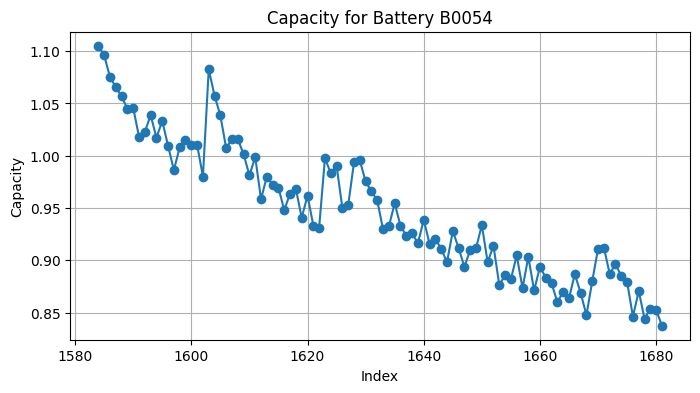

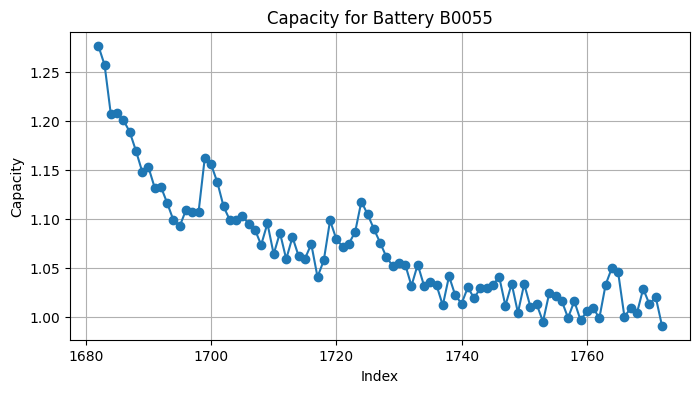

In [65]:
import matplotlib.pyplot as plt

for battery in cleaned['battery_id'].unique():
    df_batt = cleaned[cleaned['battery_id'] == battery]

    plt.figure(figsize=(8,4))
    plt.plot(df_batt.index, df_batt['Capacity'], marker='o')
    plt.title(f"Capacity for Battery {battery}")
    plt.xlabel("Index")
    plt.ylabel("Capacity")
    plt.grid(True)
    plt.show()


In [66]:

numbers_to_keep = [
    45, 46, 32, 29, 28, 30,
    36, 6, 5, 7, 18
]

keep_ids = [f"B{n:04d}" for n in numbers_to_keep]

# Optional: if battery_id has stray spaces/case differences, normalize first
cleaned['battery_id'] = cleaned['battery_id'].astype(str).str.strip().str.upper()

# ---- 5) Filter to only the selected battery_ids ----
cleaned = cleaned[cleaned['battery_id'].isin(keep_ids)].copy()

In [67]:
cleaned.columns

Index(['Unnamed: 0', 'type', 'start_time', 'ambient_temperature', 'battery_id',
       'test_id', 'uid', 'filename', 'Capacity', 'cycle_no',
       'max_capacity_per_battery'],
      dtype='object')

In [68]:
cleaned.drop(['Unnamed: 0', 'type','test_id','uid','start_time'],axis = 1, inplace = True)

In [69]:

import plotly.graph_objects as go

# Ensure index is available for x-axis (use df_batt.index as in Matplotlib)
for battery in cleaned['battery_id'].unique():
    df_batt = cleaned[cleaned['battery_id'] == battery]

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=df_batt.index,
            y=df_batt['Capacity'],
            mode='lines+markers',
            name=f'Battery {battery}',
            marker=dict(symbol='circle')
        )
    )

    fig.update_layout(
        title=f"Capacity for Battery {battery}",
        xaxis_title="Index",
        yaxis_title="Capacity",
        template="plotly_white"
    )

    fig.update_xaxes(showgrid=True)
    fig.update_yaxes(showgrid=True)

    fig.show()


In [70]:
cleaned = cleaned.drop(cleaned.index[1106:1148])
cleaned= cleaned.reset_index(drop=True)

In [71]:
import plotly.graph_objects as go

# Ensure index is available for x-axis (use df_batt.index as in Matplotlib)
for battery in cleaned['battery_id'].unique():
    df_batt = cleaned[cleaned['battery_id'] == battery]

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=df_batt.index,
            y=df_batt['Capacity'],
            mode='lines+markers',
            name=f'Battery {battery}',
            marker=dict(symbol='circle')
        )
    )

    fig.update_layout(
        title=f"Capacity for Battery {battery}",
        xaxis_title="Index",
        yaxis_title="Capacity",
        template="plotly_white"
    )

    fig.update_xaxes(showgrid=True)
    fig.update_yaxes(showgrid=True)

    fig.show()


In [72]:

# Calculate SoH as ratio of Capacity to max_capacity_per_battery
cleaned['SoH'] = cleaned['Capacity'] / cleaned['max_capacity_per_battery']

# Calculate SoH_percentage as percentage
cleaned['SoH_percentage'] = cleaned['SoH'] * 100


In [73]:

import os
import glob
import pandas as pd

# -------- CONFIG --------
FOLDER = "/kaggle/working/files/SoC"  # folder containing CSVs
OUTFILE = "mega_discharge_soc_dataset.csv"

# Measurement columns present in each CSV (as provided)
MEASURE_COLS = [
    'Voltage_measured', 'Current_measured', 'Temperature_measured',
    'Current_load', 'Voltage_load', 'Time', 'delta_t', 'I_clean',
    'delta_Ah_dis', 'cum_Ah_dis', 'SoC', 'SoC_percent'
]

# Final output column order (metadata + measurements)
FINAL_COLS = [
    'ambient_temperature', 'battery_id', 'filename', 'Capacity', 'cycle_no',
    'max_capacity_per_battery', 'SoH', 'SoH_percentage',
    'Voltage_measured', 'Current_measured', 'Temperature_measured',
    'Current_load', 'Voltage_load', 'Time', 'delta_t', 'I_clean',
    'delta_Ah_dis', 'cum_Ah_dis', 'SoC', 'SoC_percent'
]

# -------- STEP 1: Prepare metadata (cleaned) --------
cleaned = cleaned.copy()

# Compute SoH and SoH_percentage if not already present
if 'SoH' not in cleaned.columns:
    cleaned['SoH'] = cleaned['Capacity'] / cleaned['max_capacity_per_battery']
if 'SoH_percentage' not in cleaned.columns:
    cleaned['SoH_percentage'] = cleaned['SoH'] * 100

def normalize_basename(basename: str) -> str:
    """Return just 'NNNNN.csv' normalized (strip path, spaces, case)."""
    base = os.path.basename(str(basename)).strip()
    return base

def to_path(basename: str) -> str:
    """Return 'discharge_SoC/NNNNN.csv' with forward slashes."""
    base = normalize_basename(basename)
    return os.path.join(FOLDER, base).replace("\\", "/")

# Normalize cleaned['filename'] to consistent path
cleaned['filename'] = cleaned['filename'].apply(to_path)

# Keep only the metadata columns we need
meta_cols = [
    'ambient_temperature', 'battery_id', 'filename', 'Capacity', 'cycle_no',
    'max_capacity_per_battery', 'SoH', 'SoH_percentage'
]
meta = cleaned[meta_cols].drop_duplicates(subset=['filename'])

# -------- STEP 2: Read only CSVs that are in cleaned --------
# All files in the folder
all_paths = sorted(glob.glob(os.path.join(FOLDER, "*.csv")))
folder_map = {normalize_basename(p): p.replace("\\", "/") for p in all_paths}

# Basenames that are referenced by cleaned
meta_basenames = [normalize_basename(p) for p in meta['filename']]

# Filter to the intersection: only files present in cleaned
paths_to_read = [folder_map[b] for b in meta_basenames if b in folder_map]

# Sanity check: ensure every meta filename is found in the folder
missing_in_folder = sorted([b for b in meta_basenames if b not in folder_map])
if missing_in_folder:
    raise FileNotFoundError(
        f"The following files from 'cleaned' are not present in {FOLDER}: {missing_in_folder[:10]}..."
        f" (showing up to 10)"
    )

frames = []
for fp in paths_to_read:
    df = pd.read_csv(fp)

    # Verify expected columns; if any missing, raise (you said no missing entries)
    missing_cols = [c for c in MEASURE_COLS if c not in df.columns]
    if missing_cols:
        raise ValueError(f"{fp} is missing columns: {missing_cols}")

    # Keep only the measurement columns (order preserved)
    df = df[MEASURE_COLS].copy()

    # Attach normalized filename to merge
    df['filename'] = fp
    frames.append(df)

# Concatenate all measurement rows
measure = pd.concat(frames, ignore_index=True)

# -------- STEP 3: Merge measurements with metadata --------
mega = measure.merge(meta, on='filename', how='left')

# Final sanity check: no missing in metadata fields
na_meta_counts = mega[meta_cols].isna().sum()
if int(na_meta_counts.sum()) != 0:
    raise ValueError(f"Found missing metadata values after merge:\n{na_meta_counts}")

# -------- STEP 4: Reorder columns and save --------
mega = mega.reindex(columns=FINAL_COLS)
mega.to_csv(OUTFILE, index=False)

print(f"✅ Mega dataset saved to: {OUTFILE}")
print(f"Rows: {len(mega):,} | Columns: {len(mega.columns)}")

# Optional: quick diagnostics for extras in folder (not used)
extras_in_folder = sorted(set(folder_map.keys()) - set(meta_basenames))
if extras_in_folder:
    print(f"ℹ️ Note: {len(extras_in_folder)} extra CSVs in folder not listed in 'cleaned' "
          f"(e.g., {extras_in_folder[:10]}...). They were skipped.")


✅ Mega dataset saved to: mega_discharge_soc_dataset.csv
Rows: 286,083 | Columns: 20
ℹ️ Note: 945 extra CSVs in folder not listed in 'cleaned' (e.g., ['00001.csv', '00005.csv', '00007.csv', '00009.csv', '00011.csv', '00013.csv', '00017.csv', '00021.csv', '00023.csv', '00025.csv']...). They were skipped.


In [74]:
mega.drop(['filename'],axis = 1)

,ambient_temperature,battery_id,Capacity,cycle_no,max_capacity_per_battery,SoH,SoH_percentage,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time,delta_t,I_clean,delta_Ah_dis,cum_Ah_dis,SoC,SoC_percent
0,24,B0005,1.856487,1,1.856487,1.000000,100.000000,4.191492,-0.004902,24.330034,-0.0006,0.000,0.000,0.000,-0.004902,0.000000,0.000000,1.000000,100.000000
1,24,B0005,1.856487,1,1.856487,1.000000,100.000000,4.190749,-0.001478,24.325993,-0.0006,4.206,16.781,16.781,-0.001478,0.000007,0.000007,0.999996,99.999630
2,24,B0005,1.856487,1,1.856487,1.000000,100.000000,3.974871,-2.012528,24.389085,-1.9982,3.062,35.703,18.922,-2.012528,0.010578,0.010585,0.994315,99.431509
3,24,B0005,1.856487,1,1.856487,1.000000,100.000000,3.951717,-2.013979,24.544752,-1.9982,3.030,53.781,18.078,-2.013979,0.010114,0.020698,0.988883,98.888338
4,24,B0005,1.856487,1,1.856487,1.000000,100.000000,3.934352,-2.011144,24.731385,-1.9982,3.011,71.922,18.141,-2.011144,0.010134,0.030833,0.983440,98.344041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286078,4,B0046,1.153804,72,1.728239,0.667618,66.761829,2.344787,-1.004661,13.569319,0.9988,1.883,4388.719,15.437,-1.004661,0.004308,1.224422,0.013909,1.390874
286079,4,B0046,1.153804,72,1.728239,0.667618,66.761829,2.310175,-1.003274,13.698460,0.9988,1.848,4404.188,15.469,-1.003274,0.004311,1.228733,0.010437,1.043686
286080,4,B0046,1.153804,72,1.728239,0.667618,66.761829,2.273368,-1.004833,13.808871,0.9988,1.813,4419.625,15.437,-1.004833,0.004309,1.233041,0.006967,0.696677
286081,4,B0046,1.153804,72,1.728239,0.667618,66.761829,2.233415,-1.004472,13.915697,0.9988,1.774,4435.047,15.422,-1.004472,0.004303,1.237344,0.003501,0.350130


In [76]:
mega.to_csv("/kaggle/working/mega.csv", index=False)


In [86]:
import pandas as pd

def add_rul_seconds_per_cycle(
    df: pd.DataFrame,
    battery_col: str = "battery_id",
    cycle_col: str = "cycle_no",
    time_col: str = "Time",
    rul_col: str = "RUL_seconds",
    elapsed_col: str = "elapsed_seconds_in_cycle",
) -> pd.DataFrame:
    """
    Add Remaining Useful Life (RUL) in seconds for each row,
    measured *within each discharge cycle*.

    For each (battery_id, cycle_no):

        elapsed_seconds_in_cycle = Time - Time_at_start_of_cycle
        total_cycle_duration     = max(elapsed_seconds_in_cycle)
        RUL_seconds              = total_cycle_duration - elapsed_seconds_in_cycle
    """

    # ---- basic checks ----
    if battery_col not in df.columns:
        raise ValueError(f"Required column '{battery_col}' not in dataframe.")
    if cycle_col not in df.columns:
        raise ValueError(f"Required column '{cycle_col}' not in dataframe.")
    if time_col not in df.columns:
        raise ValueError(f"Required column '{time_col}' not in dataframe.")

    # Work on a sorted copy
    df_sorted = df.sort_values([battery_col, cycle_col, time_col]).copy()

    # Ensure time is numeric
    df_sorted[time_col] = pd.to_numeric(df_sorted[time_col], errors="coerce")
    if df_sorted[time_col].isna().any():
        raise ValueError(
            f"Column '{time_col}' contains NaNs or non-numeric values after coercion."
        )

    # Elapsed time within each cycle (make sure first time in each cycle is 0)
    first_time = df_sorted.groupby([battery_col, cycle_col])[time_col].transform("min")
    df_sorted[elapsed_col] = df_sorted[time_col] - first_time

    # Total duration of each cycle
    total_duration = df_sorted.groupby([battery_col, cycle_col])[elapsed_col].transform("max")

    # RUL in seconds for this discharge
    df_sorted[rul_col] = total_duration - df_sorted[elapsed_col]

    return df_sorted


In [87]:
import pandas as pd

df = pd.read_csv("mega.csv")

df_with_rul = add_rul_seconds_per_cycle(df)

# Quick sanity check: RUL should go to 0 at the end of each cycle
print(
    df_with_rul[["battery_id", "cycle_no", "Time",
                 "elapsed_seconds_in_cycle", "RUL_seconds"]].head()
)

# Optional: save
df_with_rul.to_csv("mega_with_rul_per_cycle.csv", index=False)


  battery_id  cycle_no    Time  elapsed_seconds_in_cycle  RUL_seconds
0      B0005         1   0.000                     0.000     3690.234
1      B0005         1  16.781                    16.781     3673.453
2      B0005         1  35.703                    35.703     3654.531
3      B0005         1  53.781                    53.781     3636.453
4      B0005         1  71.922                    71.922     3618.312


In [82]:
df_with_rul.columns

Index(['ambient_temperature', 'battery_id', 'filename', 'Capacity', 'cycle_no',
       'max_capacity_per_battery', 'SoH', 'SoH_percentage', 'Voltage_measured',
       'Current_measured', 'Temperature_measured', 'Current_load',
       'Voltage_load', 'Time', 'delta_t', 'I_clean', 'delta_Ah_dis',
       'cum_Ah_dis', 'SoC', 'SoC_percent', 'elapsed_seconds', 'RUL_seconds'],
      dtype='object')

In [83]:
df_with_rul['Time']

0            0.000
1           16.781
2           35.703
3           53.781
4           71.922
            ...   
286078    4388.719
286079    4404.188
286080    4419.625
286081    4435.047
286082    4450.625
Name: Time, Length: 286083, dtype: float64

In [85]:
df_with_rul['RUL_seconds']

0         525760.013
1         525743.232
2         525724.310
3         525706.232
4         525688.091
             ...    
286078        61.906
286079        46.437
286080        31.000
286081        15.578
286082         0.000
Name: RUL_seconds, Length: 286083, dtype: float64

In [88]:
max_time = df.loc[df["battery_id"] == "B0005", "Time"].max()
print("Max Time for B0005:", max_time)

Max Time for B0005: 3690.234
